# Import Prerequisites

In [25]:
import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from tabulate import tabulate
warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [26]:
case_time = pd.read_csv('districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [27]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [50]:
state = 'Delhi'
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
43,2020-04-26,Delhi,Delhi,2918,877,54
454,2020-04-27,Delhi,Delhi,3108,877,54
879,2020-04-28,Delhi,Delhi,3314,1078,54
1309,2020-04-29,Delhi,Delhi,3439,1092,56
1743,2020-04-30,Delhi,Delhi,3515,1094,59
2180,2020-05-01,Delhi,Delhi,3738,1167,61
2623,2020-05-02,Delhi,Delhi,4122,1256,64
3072,2020-05-03,Delhi,Delhi,4549,1362,64
3529,2020-05-04,Delhi,Delhi,4898,1431,64
3989,2020-05-05,Delhi,Delhi,5104,1468,64


In [51]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [52]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [53]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [54]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2020
|| = ||


In [55]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2021
|| = ||


Trend of Active cases in Delhi for the year 2020


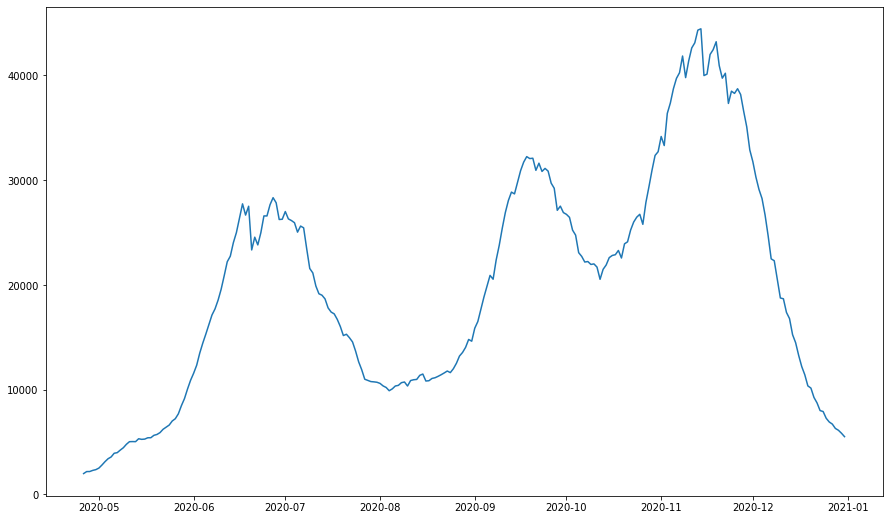

In [59]:
district = 'Delhi'
pd.set_option('display.max_rows',466)
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of COVID-19 cases in Delhi for the year 2021



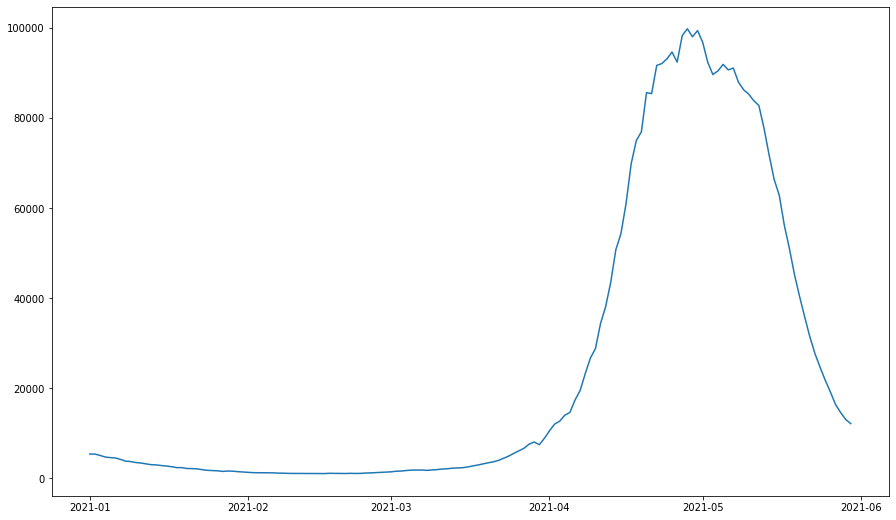

In [60]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of COVID-19 cases in",district,"for the year 2021\n")
plt.plot(bang_data_21)

In [61]:
# Divide dataset quarterly

quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Delhi
            Active
Date              
2020-04-26    1987
2020-04-27    2177
2020-04-28    2182
2020-04-29    2291
2020-04-30    2362
2020-05-01    2510
2020-05-02    2802
2020-05-03    3123
2020-05-04    3403
2020-05-05    3572
2020-05-06    3925
2020-05-07    3983
2020-05-08    4230
2020-05-09    4454
2020-05-10    4781
2020-05-11    5031
2020-05-12    5041
2020-05-13    5034
2020-05-14    5310
2020-05-15    5254
2020-05-16    5278
2020-05-17    5405
2020-05-18    5409
2020-05-19    5638
2020-05-20    5720
2020-05-21    5898
2020-05-22    6214
2020-05-23    6412
2020-05-24    6617
2020-05-25    7006
2020-05-26    7223
2020-05-27    7690
2020-05-28    8470
2020-05-29    9142
2020-05-30   10058
2020-05-31   10893
2020-06-01   11565
2020-06-02   12333
2020-06-03   13488
2020-06-04   14447
2020-06-05   15311
2020-06-06   16229
2020-06-07   17125
2020-06-08   17712
2020-06-09   18543
2020-06-10   19581
2020-06-11   20871
2020-06-12   22212
2020-06-13   22742
2020-06

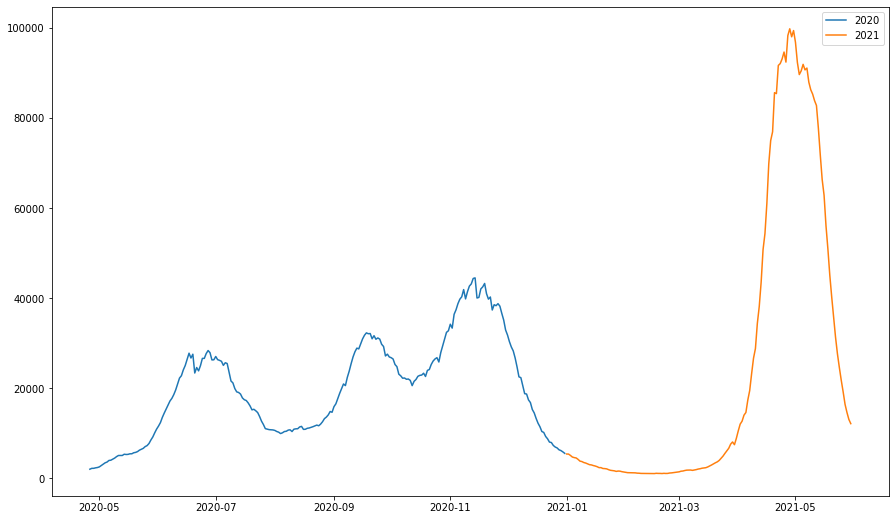

In [62]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# Exponential Smoothing

In [63]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Forecast of trend of growth of COVID-19 for the 1st test-interval


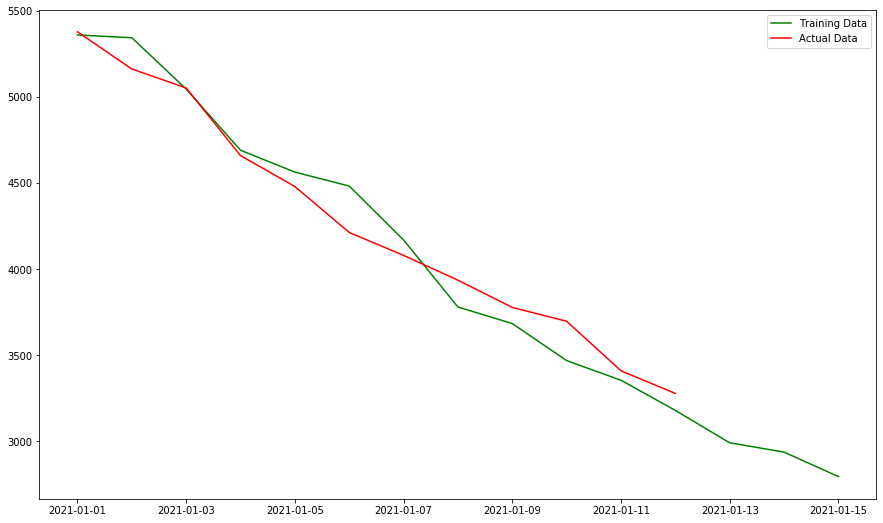

In [64]:
number_of_days = 12
model = ExponentialSmoothing(bang_data,trend='mul',seasonal='mul',seasonal_periods=7).fit()
ress = model.forecast(number_of_days)
print("Forecast of trend of growth of COVID-19 for the 1st test-interval")
plt.plot(bang_data_21[:number_of_days + 3 ],color="green")
plt.plot(ress,color="red")
plt.legend(['Training Data','Actual Data','Forecast'])

In [65]:
lst = bang_data_21.values
sm = 0
l = min(len(bang_data_21),len(ress))
for i in range(l):
    x = (ress[i]-lst[i])**2
    sm = sm + x
rmse = math.sqrt(sm/l)
print('RMSE:',rmse)

RMSE: 135.29203561393766


In [66]:
error_vals =[]

def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [67]:
rmse_for_tab = []
model = ExponentialSmoothing(quart4_data,trend='mul',seasonal='mul',seasonal_periods=7).fit()
for i in range(1,15):
    period = int(i)
    ress = model.forecast(period)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)
error_vals.append(rmse_for_tab)

In [68]:
Q3_4 = pd.concat([quart3_data,quart4_data])

rmse_for_tab = []
model = ExponentialSmoothing(Q3_4,trend='mul',seasonal='mul',seasonal_periods=7).fit()
for i in range(1,15):
    period = int(i)
    ress = model.forecast(period)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)
error_vals.append(rmse_for_tab)

In [69]:
rmse_for_tab = []
model = ExponentialSmoothing(bang_data,trend='mul',seasonal='mul',seasonal_periods=7).fit()
for i in range(1,15):
    period = int(i)
    ress = model.forecast(period)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)
error_vals.append(rmse_for_tab)

In [70]:
eval_matrix = pd.DataFrame(columns=['Time frame','Date','Quarter 4 data','Quarter 4 and 3 data','All data'])

In [71]:
tim = []
print("Error comparission for different dataset sizes")
for i in range(len(error_vals[0])):
    tim.append((i+1))
eval_matrix['Time frame'] = tim
eval_matrix['Date'] = bang_data_21.index[:14]
eval_matrix['Quarter 4 data'] = error_vals[0]
eval_matrix['Quarter 4 and 3 data'] = error_vals[1]
eval_matrix['All data'] = error_vals[2]
eval_matrix.set_index('Time frame',inplace=True)
eval_matrix

Error comparission for different dataset sizes


,Date,Quarter 4 data,Quarter 4 and 3 data,All data
Time frame,,,,
1,2021-01-01,98.477535,99.758730,99.655306
2,2021-01-02,96.168183,96.593244,97.584423
3,2021-01-03,96.825564,96.386083,98.026299
4,2021-01-04,97.241405,95.417405,98.258697
5,2021-01-05,97.495705,94.699167,98.239686
6,2021-01-06,96.896004,93.463791,97.067714
7,2021-01-07,96.985146,93.453486,97.166968
8,2021-01-08,97.000344,93.871670,96.975429
9,2021-01-09,97.137557,94.104824,97.024931


Forecast of trend of growth of COVID-19 for the 2nd test interval
Date                   Daily    Cumulative    Confidence Interval    Daily    Cumulative
-------------------  -------  ------------  ---------------------  -------  ------------
2021-05-22 00:00:00    -4195         32516                99.6553    -4375         31308
2021-05-23 00:00:00    -3344         29171                97.5844    -3698         27610
2021-05-24 00:00:00    -3638         25533                98.0263    -3032         24578
2021-05-25 00:00:00    -2362         23170                98.2587    -2839         21739
2021-05-26 00:00:00    -2237         20933                98.2397    -2591         19148
2021-05-27 00:00:00    -1947         18985                97.0677    -2770         16378
2021-05-28 00:00:00    -1868         17117                97.167     -1797         14581
2021-05-29 00:00:00    -1956         15160                96.9754    -1546         13035


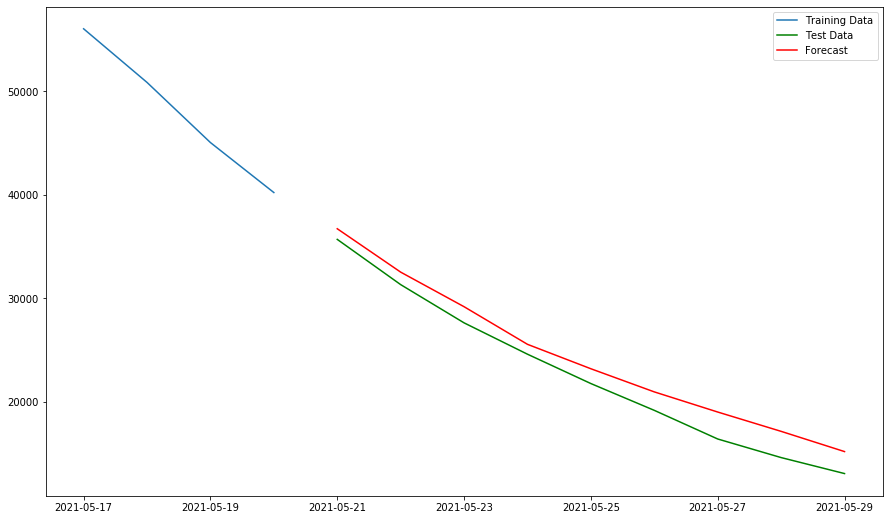

In [72]:
all_data = pd.concat([bang_data,bang_data_21[:-1]])
dayss = 9
trdata = all_data[:-dayss]
tsdata = all_data[-dayss:]
model = ExponentialSmoothing(trdata,trend='mul',seasonal='mul',seasonal_periods=7).fit()
ress = model.forecast(dayss)
print("Forecast of trend of growth of COVID-19 for the 2nd test interval")

        
plt.plot(trdata[-int(dayss/2):])
plt.plot(tsdata,color='green')
plt.plot(ress,color='red')
plt.legend(['Training Data','Test Data','Forecast'])

cum = ress.values
dates = ress.index
daily = []
daily.append(cum[0]-trdata[-1:].values)
data = []
for i in range(1,len(cum)):
    dd = []
    daily.append(cum[i]-cum[i-1])
    dts = tsdata.values[i] - tsdata.values[i-1]
    dd = [dates[i],int(daily[i]),int(cum[i]),eval_matrix['All data'][i],dts,tsdata.values[i]]
    data.append(dd)
print(tabulate(data,headers=['Date','Daily','Cumulative','Confidence Interval','Daily','Cumulative']))

# Future forecast

Future forecast of COVID-19 cases for 8 days
Date                   Daily    Cumulative    Confidence Interval
-------------------  -------  ------------  ---------------------
2021-05-31 00:00:00    -1544          9823                99.6553
2021-06-01 00:00:00    -1115          8708                97.5844
2021-06-02 00:00:00     -991          7716                98.0263
2021-06-03 00:00:00     -903          6813                98.2587
2021-06-04 00:00:00     -736          6076                98.2397
2021-06-05 00:00:00     -775          5300                97.0677
2021-06-06 00:00:00     -629          4670                97.167
2021-06-07 00:00:00     -634          4036                96.9754


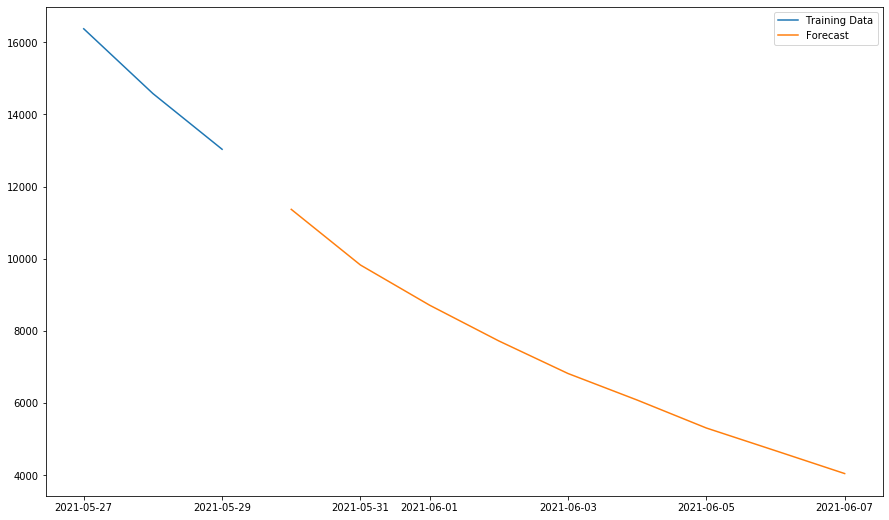

In [73]:
all_data = pd.concat([bang_data,bang_data_21])
model = ExponentialSmoothing(all_data[:-1],trend='mul',seasonal='mul',seasonal_periods=7).fit()
ress = model.forecast(dayss)
plt.plot(all_data[-int(dayss/2):-1])
plt.plot(ress)
plt.legend(['Training Data','Forecast'])
print("Future forecast of COVID-19 cases for",dayss-1,"days")

cum = ress.values
dates = ress.index
daily = []
daily.append(cum[0]-all_data[-1:].values)
data = []
for i in range(1,len(cum)):
    dd = []
    daily.append(cum[i]-cum[i-1])
    dd = [dates[i],int(daily[i]),int(cum[i]),eval_matrix['All data'][i]]
    data.append(dd)
print(tabulate(data,headers=['Date','Daily','Cumulative','Confidence Interval']))